# Analysis of Blend Methods on DRAEM Performance

This notebook analyzes the influence of different `blend_method` values on evaluation metrics:
- Image-level AUROC and AP
- Pixel-level AUROC and AP

Data is fetched from Weights & Biases runs and analyzed across different object classes.

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Fetch Data from W&B

In [ ]:
# Initialize W&B API
api = wandb.Api()

# Fetch runs from the project
entity = "team-cr"
project = "DRAEM_seminar_AD"

print(f"Fetching runs from {entity}/{project}...")
runs = api.runs(f"{entity}/{project}")

print(f"Total runs found: {len(runs)}")

metrics = [
        'eval/auroc_image',
        'eval/ap_image',
        'eval/auroc_pixel',
        'eval/ap_pixel'
    ]


Fetching runs from team-cr/DRAEM_seminar_AD...
Total runs found: 661


## 2. Extract Relevant Metrics

In [ ]:
# Extract data from runs
data = []
from tqdm import tqdm

for run in tqdm(runs, desc="Processing runs"):
    # Check if run has blend_method in config")
    if 'blend_method' not in list(run.config.keys()):
        continue
    
    if 'blending_methods' not in run.tags:
        continue
    
    blend_method = run.config.get('blend_method', None)
    obj_name = run.config.get('obj_name', None)
    
    if blend_method is None or obj_name is None:
        continue
    
    # Get the final metrics (last epoch)
    history = run.history()
    
    if len(history) == 0:
        continue
    
    # Get metrics of interest
    metrics_to_extract = metrics    
    # Get last valid values for each metric
    run_data = {
        'run_id': run.id,
        'run_name': run.name,
        'blend_method': blend_method,
        'obj_name': obj_name,
        'state': run.state,
    }
    
    for metric in metrics_to_extract:
        if metric in history.columns:
            # Get last non-NaN value
            valid_values = history[metric].dropna()
            if len(valid_values) > 0:
                run_data[metric] = valid_values.iloc[-1]
            else:
                run_data[metric] = np.nan
        else:
            run_data[metric] = np.nan
    
    # Only add if we have at least one valid metric
    if any(not np.isnan(run_data[m]) for m in metrics_to_extract if m in run_data):
        data.append(run_data)

# Create DataFrame
df = pd.DataFrame(data)

print(f"\nExtracted data from {len(df)} runs with blend_method")
print(f"\nBlend methods found: {df['blend_method'].unique()}")
print(f"\nObject names found: {sorted(df['obj_name'].unique())}")
print(f"\nDataFrame shape: {df.shape}")

Processing runs:  29%|██▉       | 192/661 [00:00<00:01, 367.88it/s]

Processing runs:  34%|███▍      | 224/661 [00:15<00:41, 10.56it/s] 

Processing runs:  34%|███▍      | 225/661 [00:16<00:42, 10.23it/s]

Processing runs:  36%|███▋      | 241/661 [00:23<01:04,  6.48it/s]

Processing runs:  38%|███▊      | 250/661 [00:27<01:19,  5.17it/s]

...

Processing runs:  92%|█████████▏| 608/661 [03:14<00:23,  2.30it/s]

Processing runs:  92%|█████████▏| 609/661 [03:15<00:22,  2.32it/s]

Processing runs:  92%|█████████▏| 610/661 [03:15<00:23,  2.17it/s]

Processing runs:  92%|█████████▏| 611/661 [03:16<00:16,  3.12it/s]

420
Extracted data from 420 runs with blend_method

Blend methods found: ['uniform_beta' 'perlin_beta' 'texture_beta' 'blurred_beta' 'poisson'
 'poisson,blurred_beta' 'poisson,texture_beta' 'poisson,perlin_beta'
 'poisson,uniform_beta']

Object names found: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']

DataFrame shape: (420, 9)


In [11]:
# Display first few rows
df.head(10)

,run_id,run_name,blend_method,obj_name,state,eval/auroc_image,eval/ap_image,eval/auroc_pixel,eval/ap_pixel
0,1az5a0bp,uniform_beta_bottle,uniform_beta,bottle,finished,0.968254,0.984636,0.992245,0.894798
1,3dj044r1,uniform_beta_bottle,uniform_beta,bottle,finished,0.958730,0.973957,0.991607,0.884204
2,5bnwz5o6,perlin_beta_bottle,perlin_beta,bottle,finished,0.983333,0.993868,0.992533,0.916338
3,5rbk72b5,texture_beta_bottle,texture_beta,bottle,finished,0.979365,0.991810,0.993592,0.919648
4,bqlhssby,perlin_beta_bottle,perlin_beta,bottle,finished,0.975397,0.990038,0.989805,0.902669
5,r2aqqmx2,texture_beta_bottle,texture_beta,bottle,finished,0.974603,0.989121,0.993679,0.916575
6,r4kdjy2m,blurred_beta_bottle,blurred_beta,bottle,finished,0.969048,0.985996,0.988346,0.867096
7,u60vrddu,blurred_beta_bottle,blurred_beta,bottle,finished,0.958730,0.974938,0.988229,0.869183
8,by8xgsea,blurred_beta_carpet,blurred_beta,carpet,finished,0.944222,0.982399,0.887042,0.504939
9,hvl03oe9,perlin_beta_carpet,perlin_beta,carpet,finished,0.930979,0.979553,0.945193,0.539111


In [12]:
# Summary statistics by blend method
print("\nRuns per blend method:")
print(df['blend_method'].value_counts())

print("\nRuns per object:")
print(df['obj_name'].value_counts())


Runs per blend method:
blend_method
uniform_beta            60
perlin_beta             60
texture_beta            60
blurred_beta            60
poisson                 60
poisson,blurred_beta    30
poisson,texture_beta    30
poisson,perlin_beta     30
poisson,uniform_beta    30
Name: count, dtype: int64

Runs per object:
obj_name
bottle        28
carpet        28
capsule       28
leather       28
pill          28
transistor    28
tile          28
cable         28
zipper        28
toothbrush    28
metal_nut     28
hazelnut      28
screw         28
grid          28
wood          28
Name: count, dtype: int64


## 3. Data Cleaning and Preparation

In [15]:
# Filter out runs with missing metrics
df_clean = df.dropna(subset=metrics)

print(f"Cleaned data: {len(df_clean)} runs with complete metrics")
print(f"Dropped {len(df) - len(df_clean)} runs with missing metrics")

Cleaned data: 420 runs with complete metrics
Dropped 0 runs with missing metrics


In [16]:
# Check data distribution
print("\nData distribution (blend_method x obj_name):")
pivot = df_clean.pivot_table(index='obj_name', columns='blend_method', aggfunc='size', fill_value=0)
print(pivot)


Data distribution (blend_method x obj_name):
blend_method  blurred_beta  perlin_beta  poisson  poisson,blurred_beta  \
obj_name                                                                 
bottle                   4            4        4                     2   
cable                    4            4        4                     2   
capsule                  4            4        4                     2   
carpet                   4            4        4                     2   
grid                     4            4        4                     2   
hazelnut                 4            4        4                     2   
leather                  4            4        4                     2   
metal_nut                4            4        4                     2   
pill                     4            4        4                     2   
screw                    4            4        4                     2   
tile                     4            4        4                  

## 4. Overall Comparison: Blend Methods

In [18]:
# Aggregate statistics by blend method
summary_stats = df_clean.groupby('blend_method')[metrics].agg(['mean', 'std', 'min', 'max', 'count'])
print("\nSummary statistics by blend method:")
print(summary_stats)


Summary statistics by blend method:
                     eval/auroc_image                                 \
                                 mean       std       min  max count   
blend_method                                                           
blurred_beta                 0.963628  0.035878  0.886250  1.0    60   
perlin_beta                  0.981772  0.024616  0.908733  1.0    60   
poisson                      0.990975  0.013484  0.939655  1.0    60   
poisson,blurred_beta         0.985728  0.020330  0.914918  1.0    30   
poisson,perlin_beta          0.992081  0.013364  0.946964  1.0    30   
poisson,texture_beta         0.990382  0.014886  0.937031  1.0    30   
poisson,uniform_beta         0.990483  0.017093  0.931409  1.0    30   
texture_beta                 0.980414  0.029633  0.865169  1.0    60   
uniform_beta                 0.980072  0.027275  0.908171  1.0    60   

                     eval/ap_image                                 \
                             

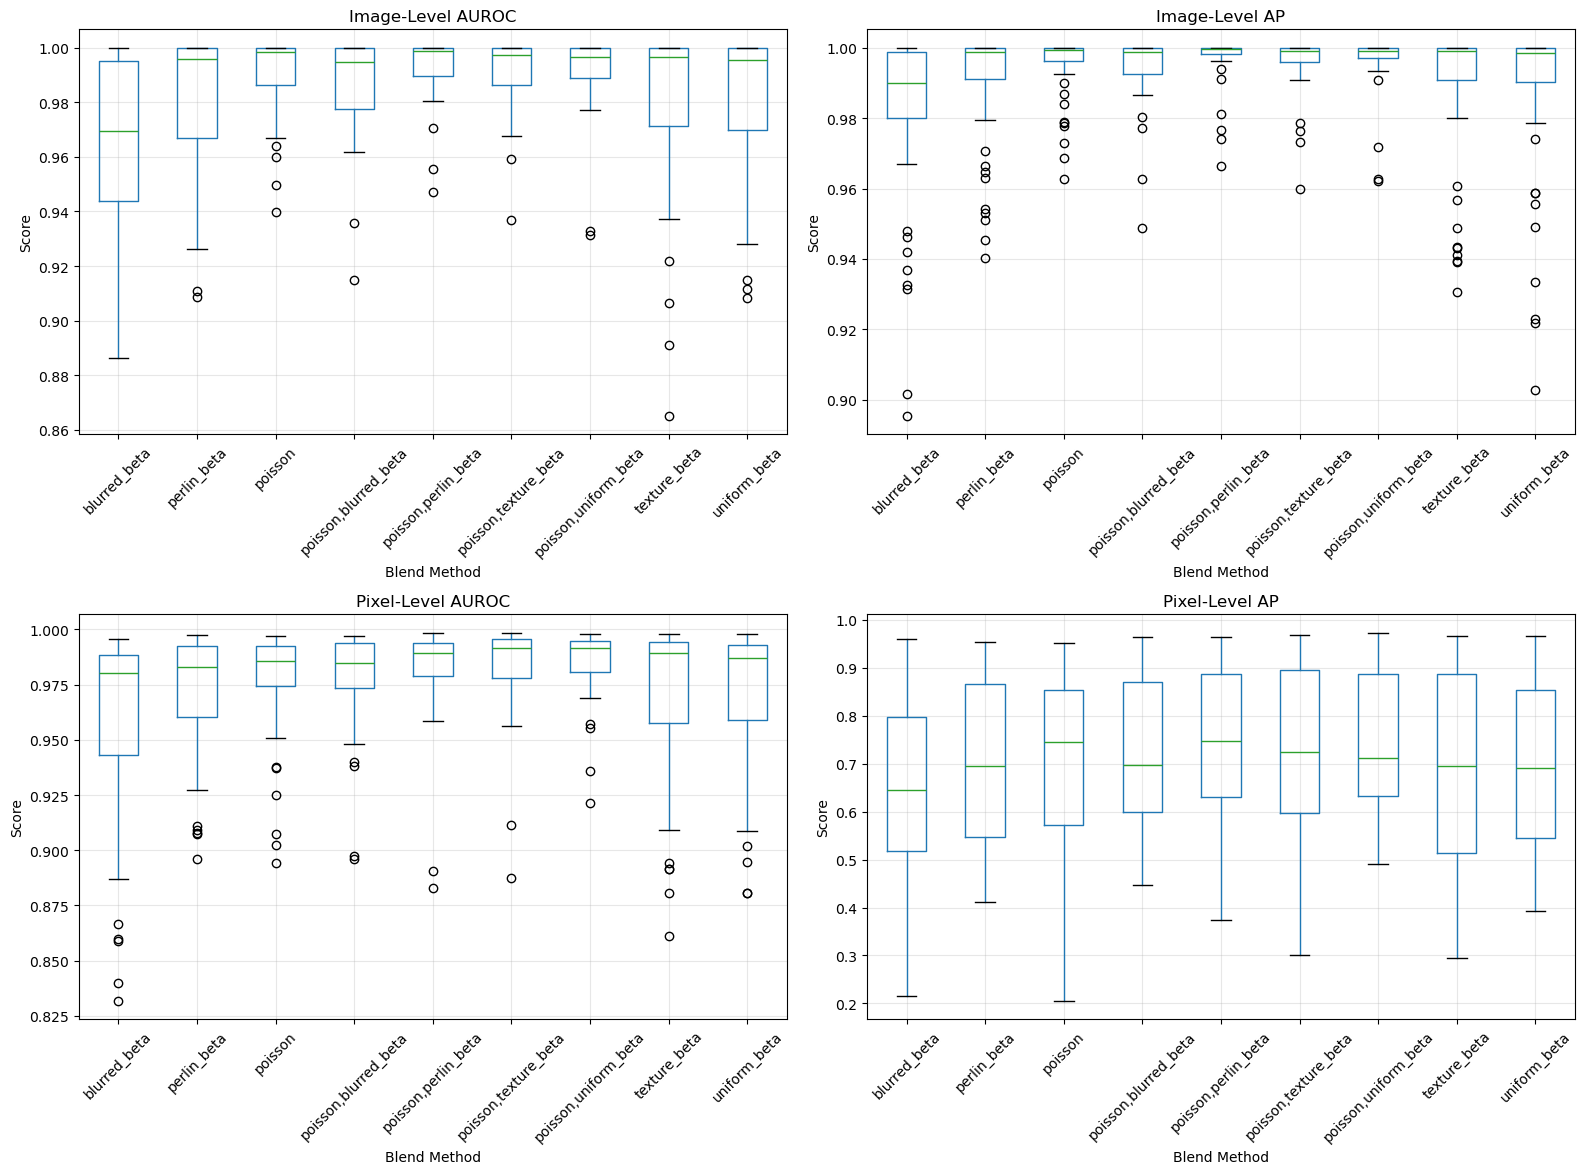

In [19]:
# Box plots for overall comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Overall Performance by Blend Method', fontsize=16, fontweight='bold')

metric_titles = [
    'Image-Level AUROC',
    'Image-Level AP',
    'Pixel-Level AUROC',
    'Pixel-Level AP'
]

for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
    ax = axes[idx // 2, idx % 2]
    
    # Box plot
    df_clean.boxplot(column=metric, by='blend_method', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Blend Method')
    ax.set_ylabel('Score')
    ax.get_figure().suptitle('')  # Remove default title
    
    # Rotate x labels if needed
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

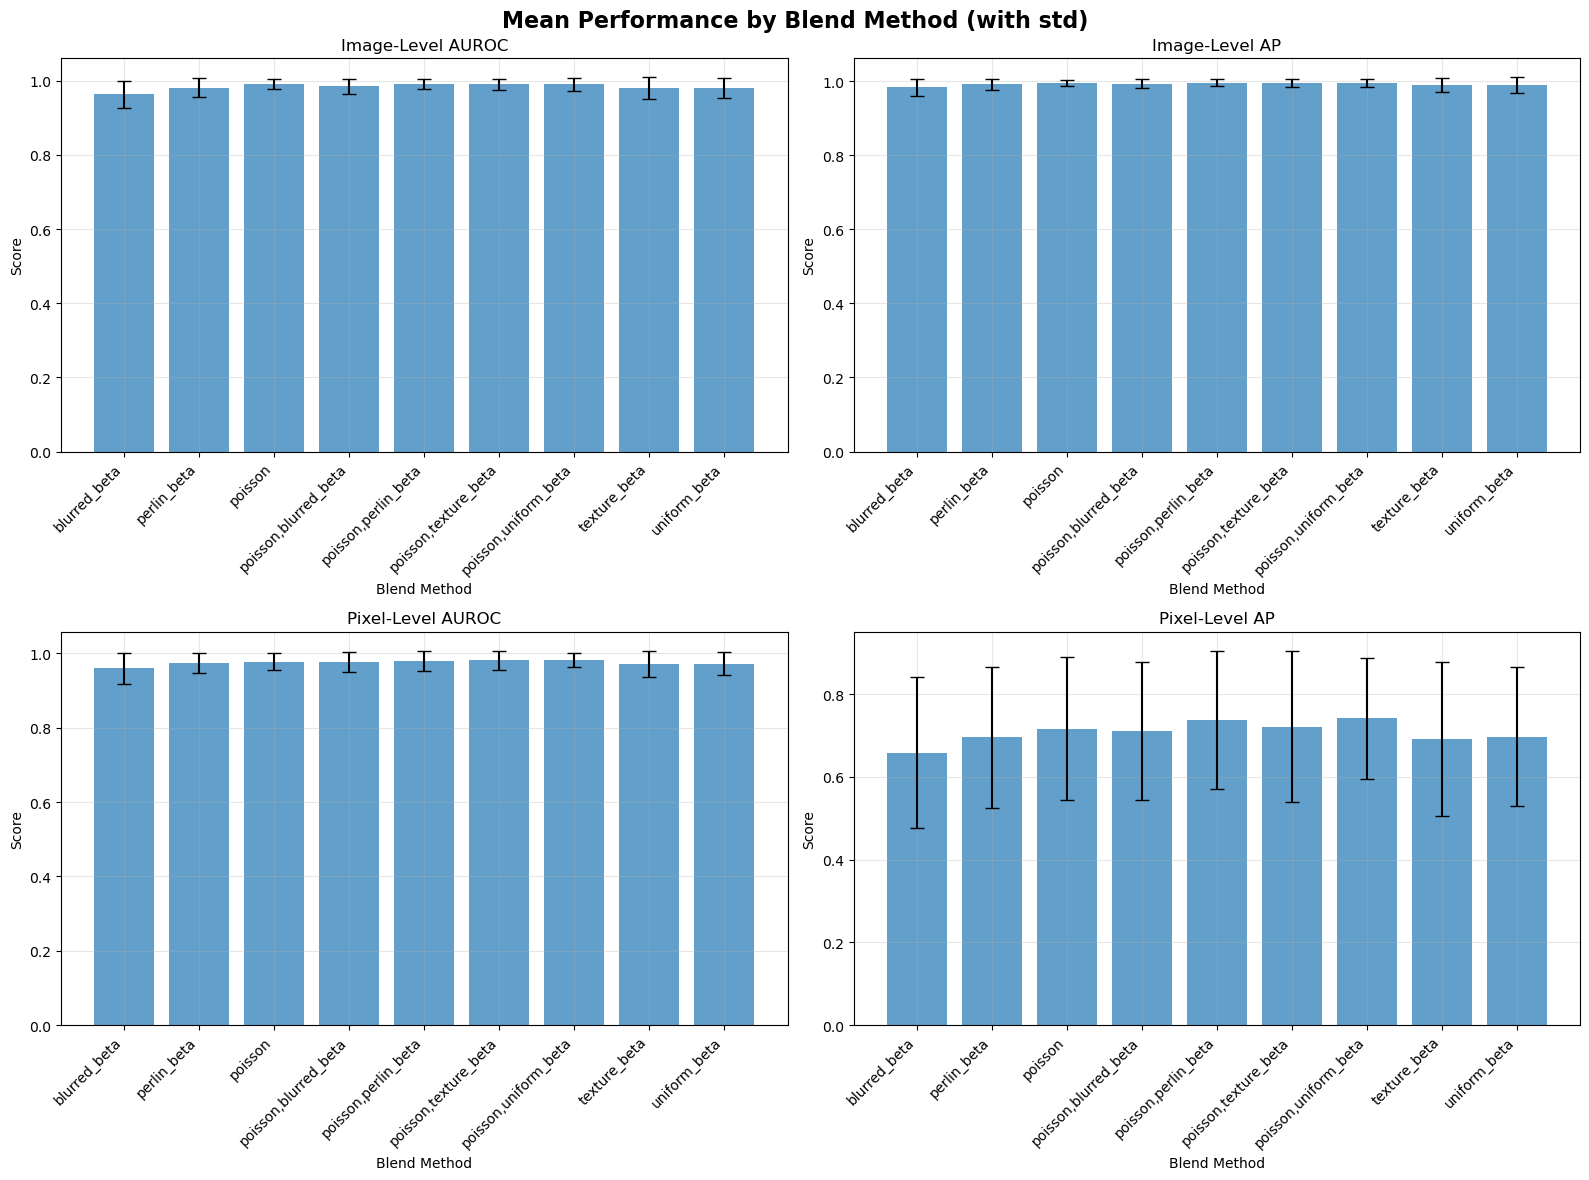

In [20]:
# Bar plots with error bars
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Mean Performance by Blend Method (with std)', fontsize=16, fontweight='bold')

for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
    ax = axes[idx // 2, idx % 2]
    
    # Calculate mean and std
    grouped = df_clean.groupby('blend_method')[metric].agg(['mean', 'std'])
    
    # Bar plot
    x_pos = np.arange(len(grouped))
    ax.bar(x_pos, grouped['mean'], yerr=grouped['std'], capsize=5, alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(grouped.index, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_xlabel('Blend Method')
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Per-Object Analysis

In [21]:
# Get list of objects and blend methods
objects = sorted(df_clean['obj_name'].unique())
blend_methods = sorted(df_clean['blend_method'].unique())

print(f"Objects: {objects}")
print(f"Blend methods: {blend_methods}")

Objects: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']
Blend methods: ['blurred_beta', 'perlin_beta', 'poisson', 'poisson,blurred_beta', 'poisson,perlin_beta', 'poisson,texture_beta', 'poisson,uniform_beta', 'texture_beta', 'uniform_beta']


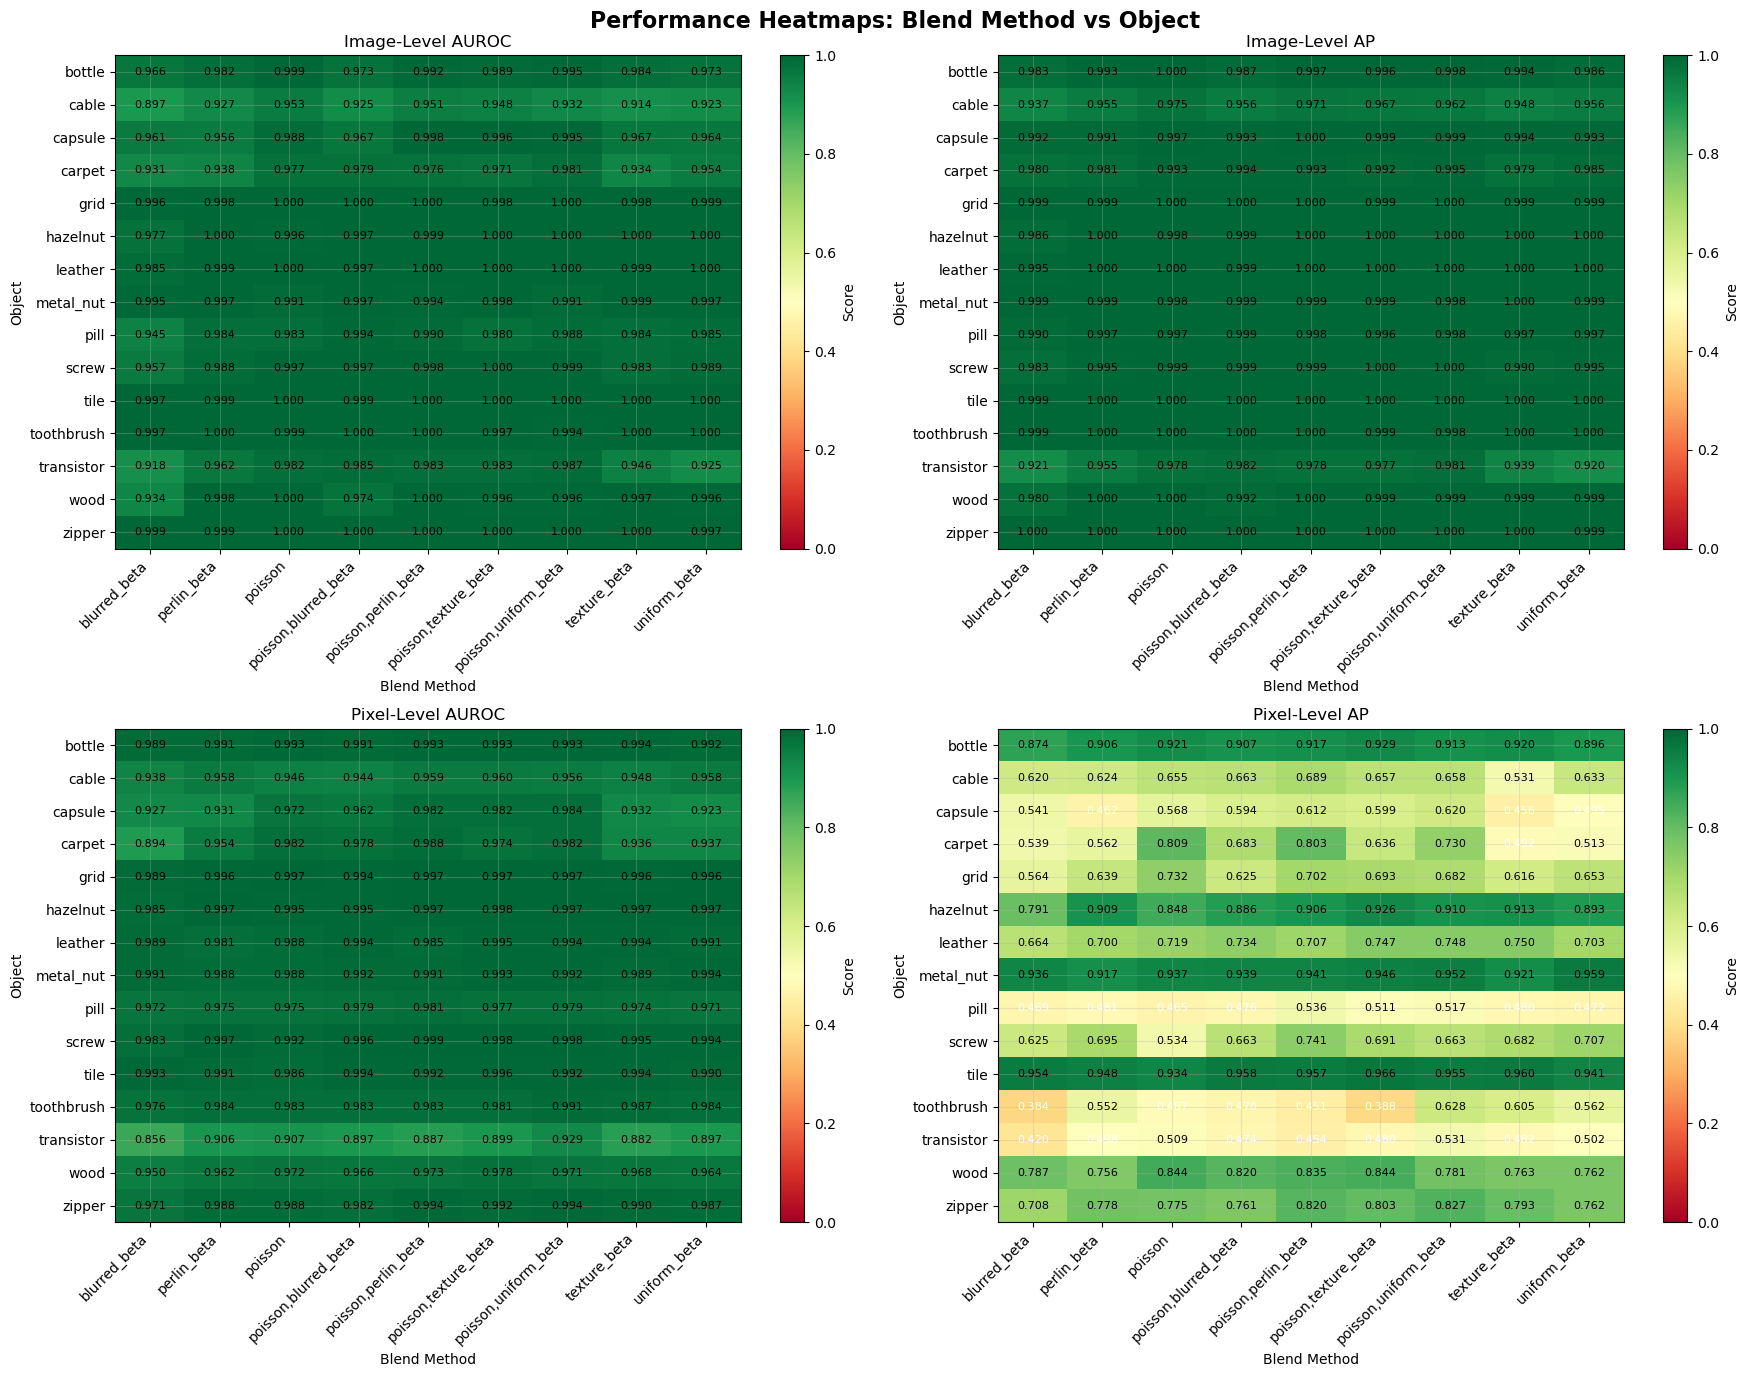

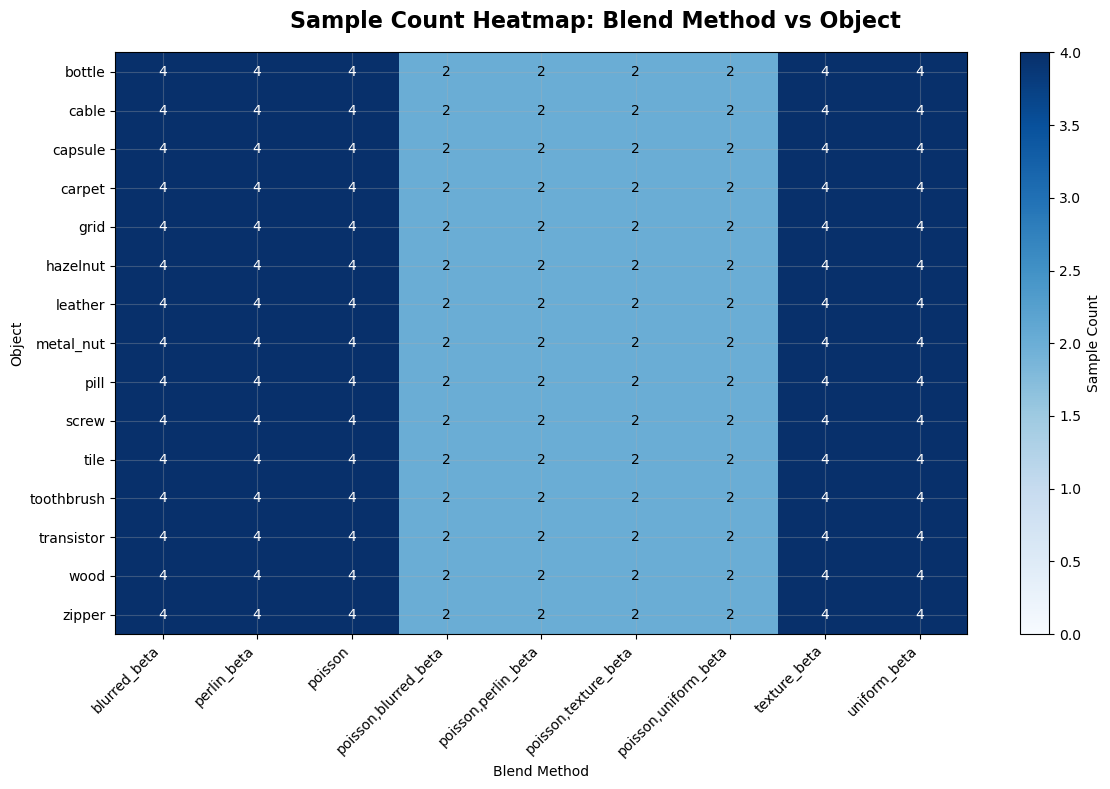

In [31]:
# Heatmap: Image-level AUROC by object and blend method
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Performance Heatmaps: Blend Method vs Object', fontsize=16, fontweight='bold')

for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
    ax = axes[idx // 2, idx % 2]
    
    # Create pivot table
    pivot_data = df_clean.pivot_table(
        values=metric,
        index='obj_name',
        columns='blend_method',
        aggfunc='mean'
    )
    
    # Heatmap using matplotlib
    im = ax.imshow(pivot_data.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(pivot_data.columns)))
    ax.set_yticks(np.arange(len(pivot_data.index)))
    ax.set_xticklabels(pivot_data.columns, rotation=45, ha='right')
    ax.set_yticklabels(pivot_data.index)
    
    # Add text annotations
    for i in range(len(pivot_data.index)):
        for j in range(len(pivot_data.columns)):
            value = pivot_data.values[i, j]
            if not np.isnan(value):
                text_color = 'white' if value < 0.5 else 'black'
                ax.text(j, i, f'{value:.3f}', ha='center', va='center', color=text_color, fontsize=8)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Score')
    
    ax.set_title(title)
    ax.set_xlabel('Blend Method')
    ax.set_ylabel('Object')

plt.tight_layout()
plt.show()

# Count-based heatmap: Sample count by object and blend method
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
fig.suptitle('Sample Count Heatmap: Blend Method vs Object', fontsize=16, fontweight='bold')

# Create pivot table for counts
count_data = df_clean.pivot_table(
    values='run_id',  # Use run_id as dummy variable to count
    index='obj_name',
    columns='blend_method',
    aggfunc='count',
    fill_value=0
)

# Heatmap using matplotlib
im = ax.imshow(count_data.values, cmap='Blues', aspect='auto', vmin=0, vmax=count_data.values.max())

# Set ticks and labels
ax.set_xticks(np.arange(len(count_data.columns)))
ax.set_yticks(np.arange(len(count_data.index)))
ax.set_xticklabels(count_data.columns, rotation=45, ha='right')
ax.set_yticklabels(count_data.index)

# Add count annotations
for i in range(len(count_data.index)):
    for j in range(len(count_data.columns)):
        count = count_data.values[i, j]
        text_color = 'white' if count > count_data.values.max() * 0.5 else 'black'
        ax.text(j, i, f'{count}', ha='center', va='center', color=text_color, fontsize=10)

# Add colorbar
plt.colorbar(im, ax=ax, label='Sample Count')

ax.set_xlabel('Blend Method')
ax.set_ylabel('Object')

plt.tight_layout()
plt.show()

## 6. Detailed Per-Object Comparison

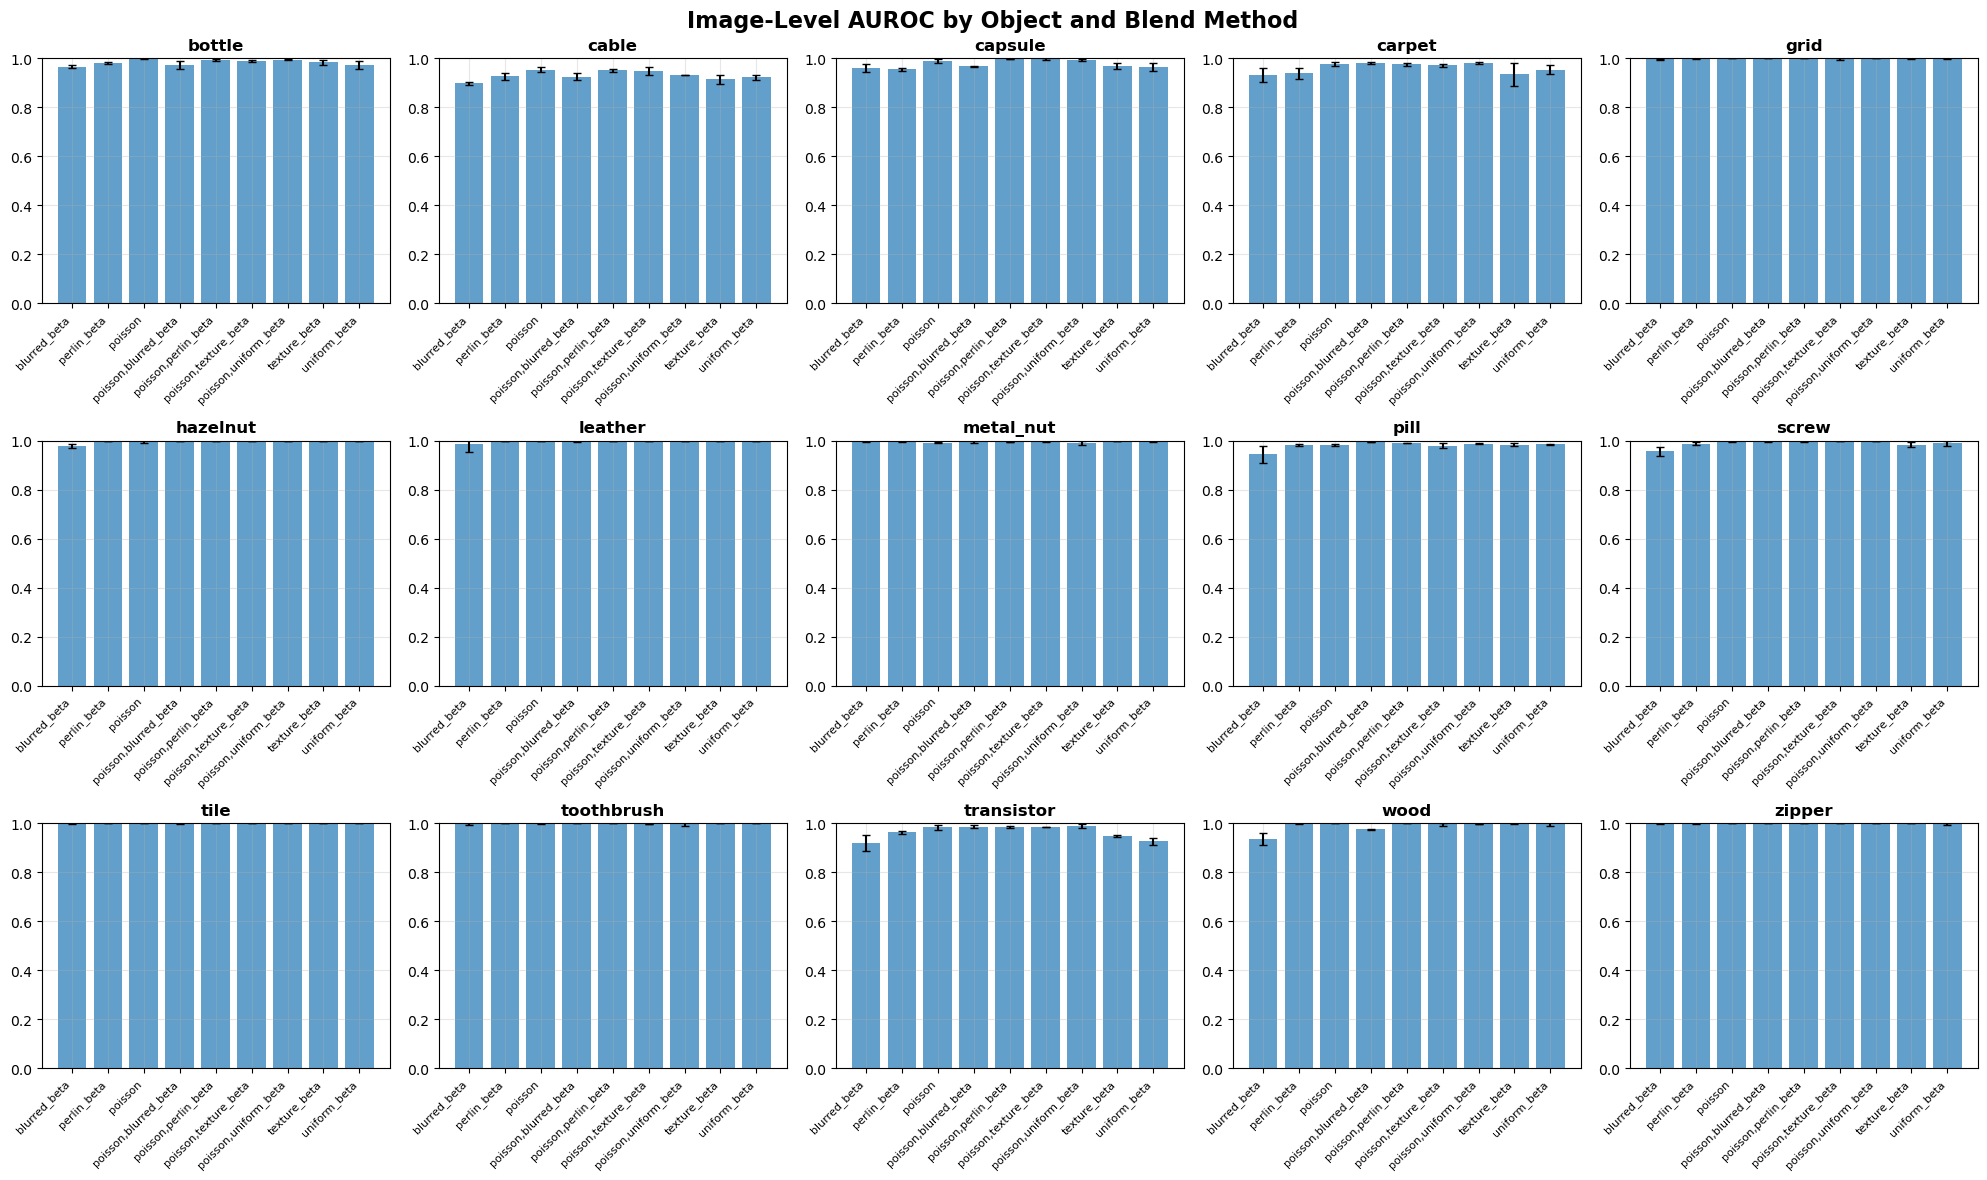

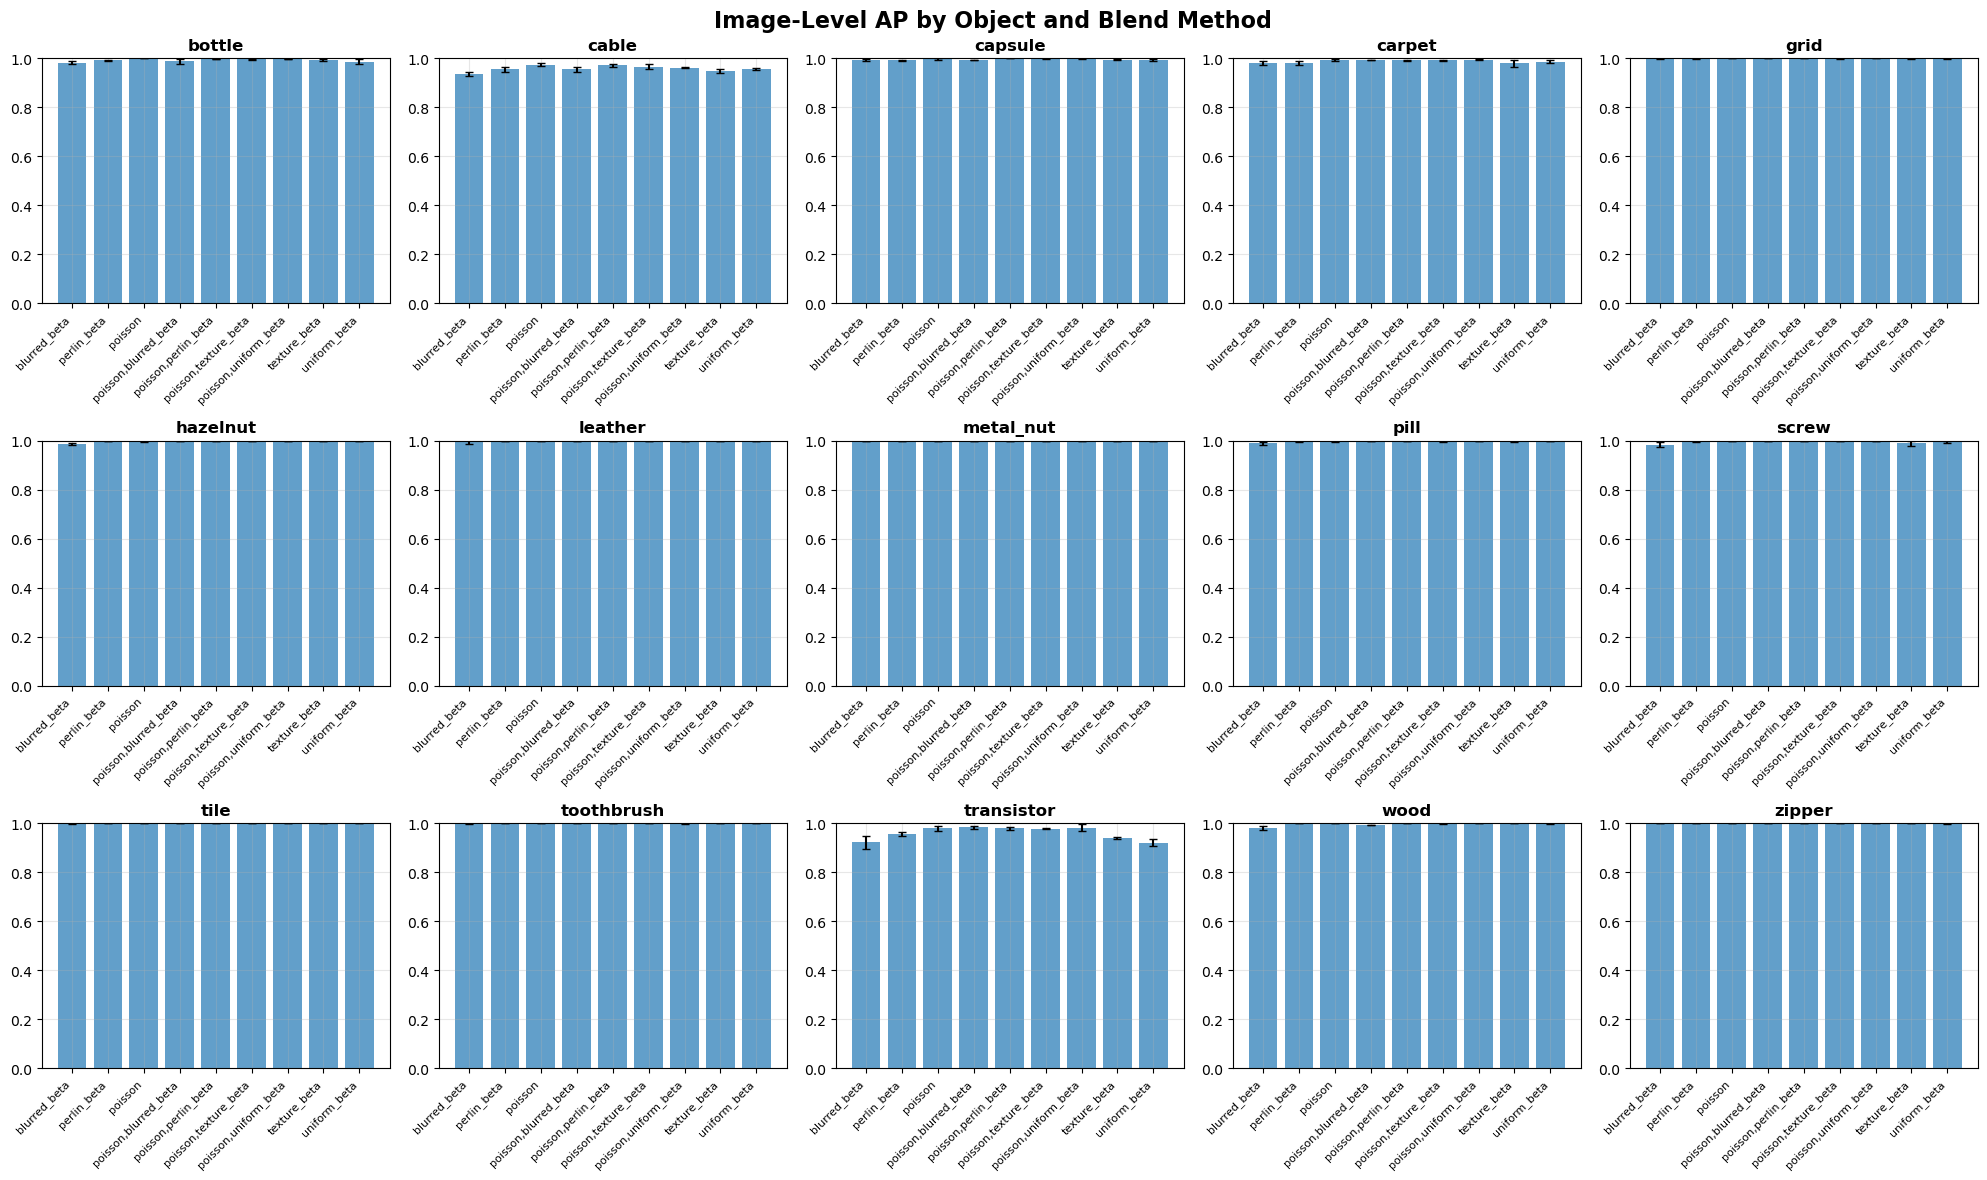

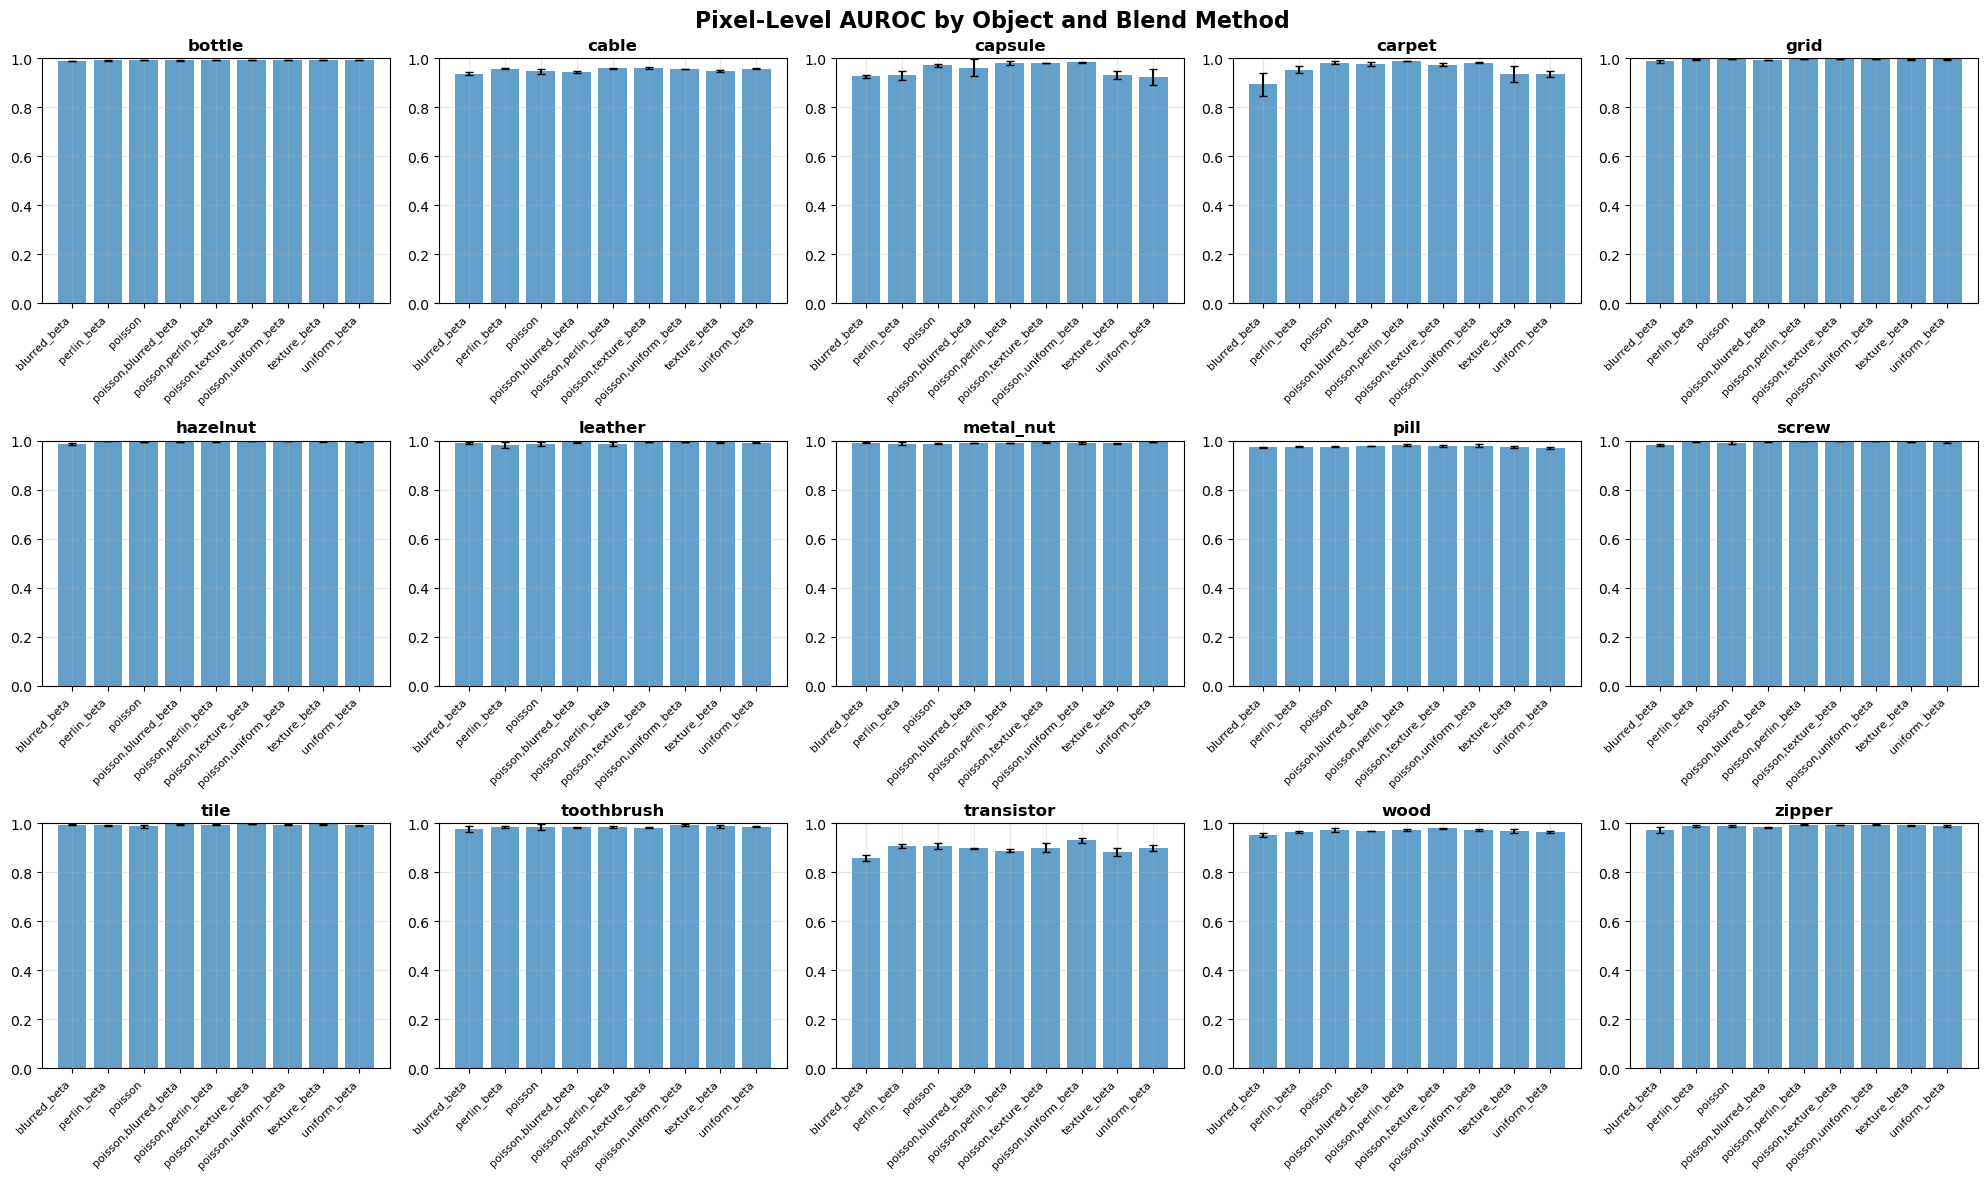

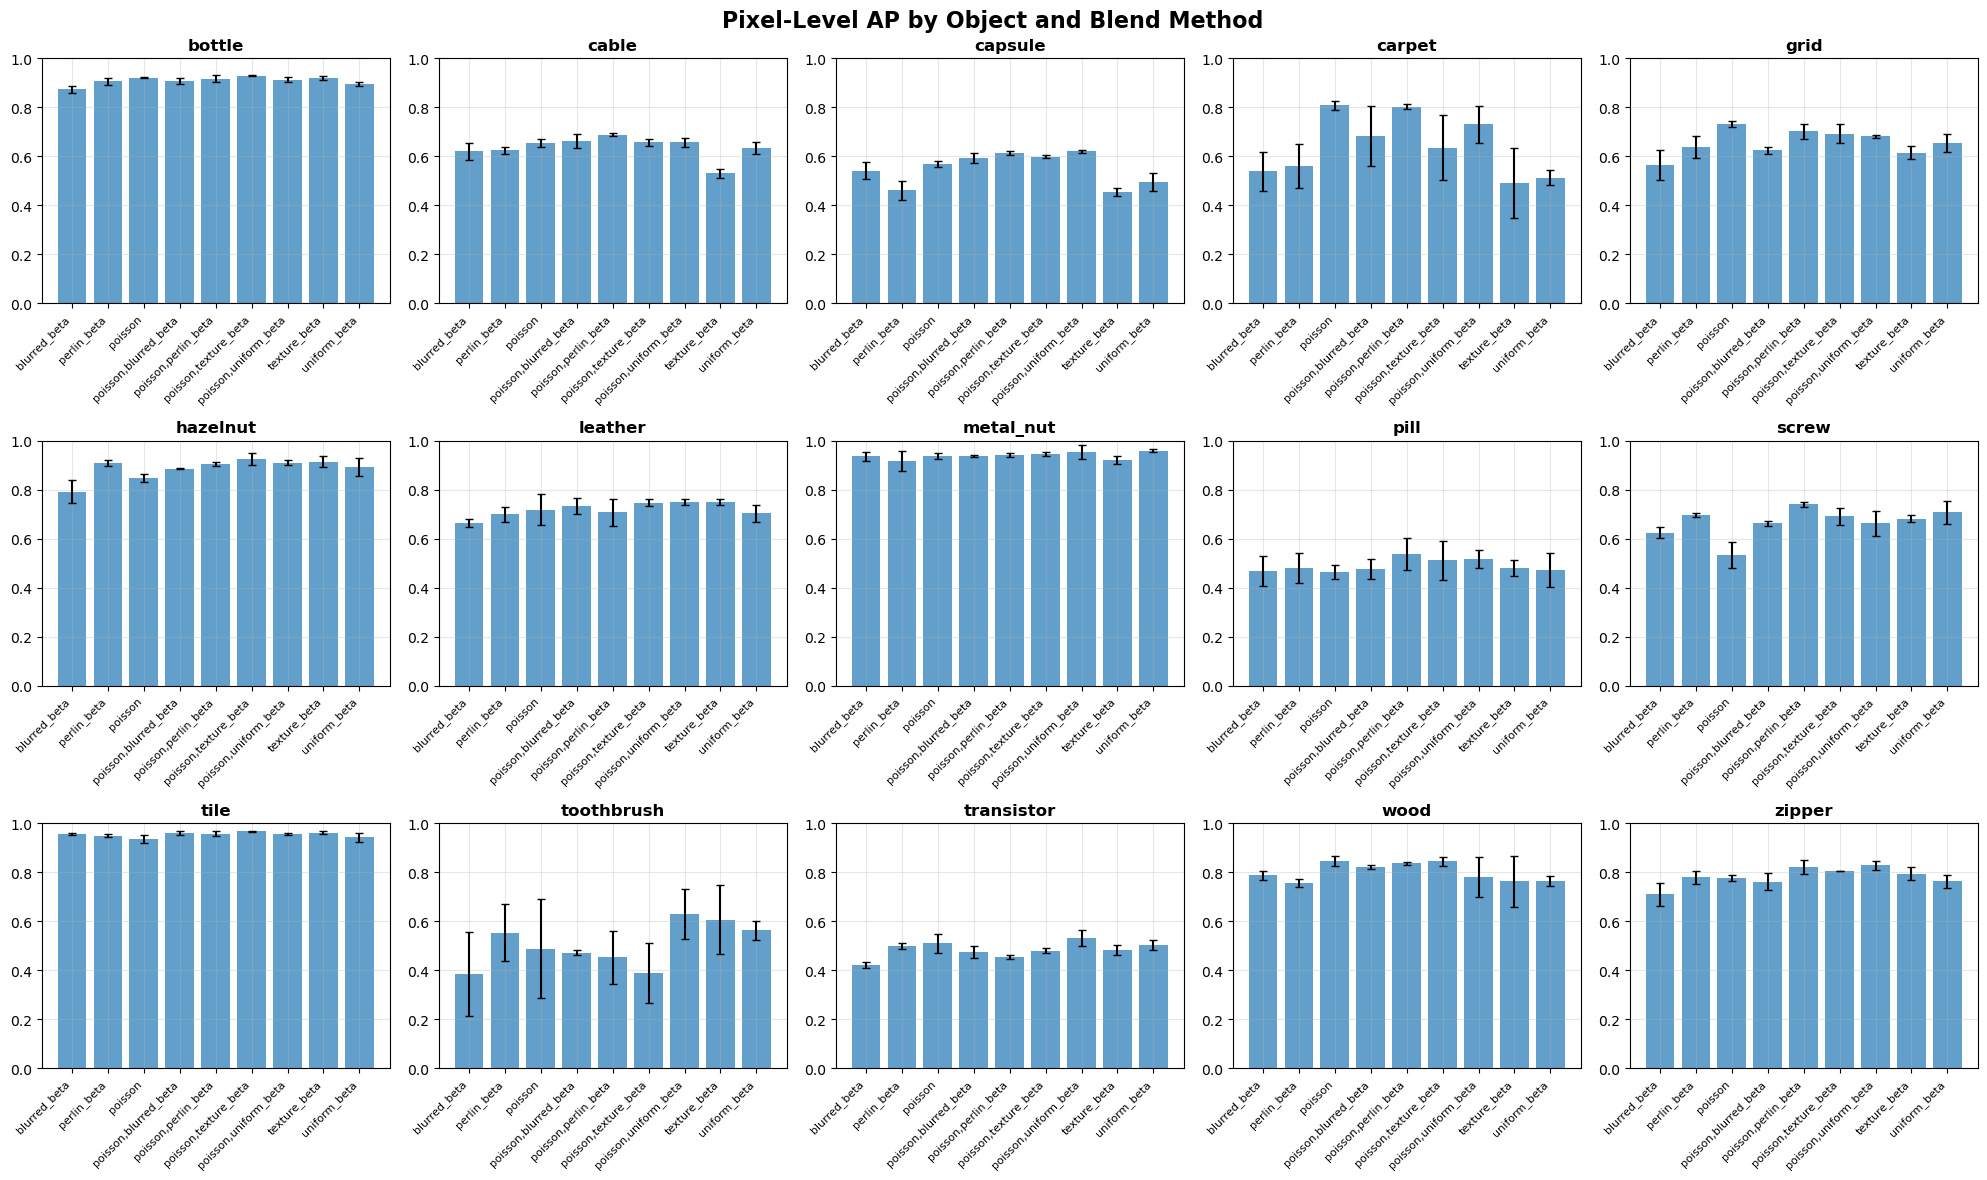

In [23]:
# Line plots: Each object's performance across blend methods
def plot_metric_by_object(metric, title):
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    fig.suptitle(f'{title} by Object and Blend Method', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    for idx, obj in enumerate(objects):
        if idx >= len(axes):
            break
        
        ax = axes[idx]
        obj_data = df_clean[df_clean['obj_name'] == obj]
        
        # Group by blend method
        grouped = obj_data.groupby('blend_method')[metric].agg(['mean', 'std'])
        
        if len(grouped) > 0:
            x_pos = np.arange(len(grouped))
            ax.bar(x_pos, grouped['mean'], yerr=grouped['std'], capsize=3, alpha=0.7)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(grouped.index, rotation=45, ha='right', fontsize=8)
            ax.set_title(obj, fontweight='bold')
            ax.set_ylim([0, 1])
            ax.grid(axis='y', alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(obj, fontweight='bold')
    
    # Hide unused subplots
    for idx in range(len(objects), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot for each metric
for metric, title in zip(metrics, metric_titles):
    plot_metric_by_object(metric, title)

## 7. Statistical Comparison

In [24]:
# Pairwise comparison of blend methods
from scipy import stats

def pairwise_ttest(df, metric, blend_methods):
    """Perform pairwise t-tests between blend methods"""
    results = pd.DataFrame(index=blend_methods, columns=blend_methods)
    
    for method1 in blend_methods:
        for method2 in blend_methods:
            if method1 == method2:
                results.loc[method1, method2] = 1.0
            else:
                data1 = df[df['blend_method'] == method1][metric].values
                data2 = df[df['blend_method'] == method2][metric].values
                
                if len(data1) > 1 and len(data2) > 1:
                    _, p_value = stats.ttest_ind(data1, data2)
                    results.loc[method1, method2] = p_value
                else:
                    results.loc[method1, method2] = np.nan
    
    return results.astype(float)

# Perform t-tests for each metric
for metric, title in zip(metrics, metric_titles):
    print(f"\n{'='*60}")
    print(f"Pairwise t-test p-values for {title}")
    print(f"{'='*60}")
    
    p_values = pairwise_ttest(df_clean, metric, blend_methods)
    print(p_values)
    print("\nNote: p < 0.05 indicates significant difference")


Pairwise t-test p-values for Image-Level AUROC
                      blurred_beta  perlin_beta       poisson  \
blurred_beta          1.000000e+00     0.001604  1.982172e-07   
perlin_beta           1.604439e-03     1.000000  1.238535e-02   
poisson               1.982172e-07     0.012385  1.000000e+00   
poisson,blurred_beta  2.397247e-03     0.449474  1.476840e-01   
poisson,perlin_beta   6.593327e-05     0.035303  7.138057e-01   
poisson,texture_beta  1.806840e-04     0.082057  8.498762e-01   
poisson,uniform_beta  2.030178e-04     0.085730  8.819162e-01   
texture_beta          6.073983e-03     0.785388  1.333060e-02   
uniform_beta          5.534521e-03     0.720717  6.404853e-03   

                      poisson,blurred_beta  poisson,perlin_beta  \
blurred_beta                      0.002397             0.000066   
perlin_beta                       0.449474             0.035303   
poisson                           0.147684             0.713806   
poisson,blurred_beta             

## 8. Ranking Analysis

In [25]:
# Rank blend methods by average performance
ranking_data = []

for metric, title in zip(metrics, metric_titles):
    ranked = df_clean.groupby('blend_method')[metric].mean().sort_values(ascending=False)
    
    print(f"\n{title} Rankings:")
    print("-" * 40)
    for rank, (method, score) in enumerate(ranked.items(), 1):
        count = len(df_clean[df_clean['blend_method'] == method])
        print(f"{rank}. {method:20s} {score:.4f} (n={count})")
        ranking_data.append({
            'metric': title,
            'rank': rank,
            'blend_method': method,
            'score': score,
            'count': count
        })

# Create ranking DataFrame
ranking_df = pd.DataFrame(ranking_data)


Image-Level AUROC Rankings:
----------------------------------------
1. poisson,perlin_beta  0.9921 (n=30)
2. poisson              0.9910 (n=60)
3. poisson,uniform_beta 0.9905 (n=30)
4. poisson,texture_beta 0.9904 (n=30)
5. poisson,blurred_beta 0.9857 (n=30)
6. perlin_beta          0.9818 (n=60)
7. texture_beta         0.9804 (n=60)
8. uniform_beta         0.9801 (n=60)
9. blurred_beta         0.9636 (n=60)

Image-Level AP Rankings:
----------------------------------------
1. poisson              0.9956 (n=60)
2. poisson,perlin_beta  0.9956 (n=30)
3. poisson,uniform_beta 0.9952 (n=30)
4. poisson,texture_beta 0.9949 (n=30)
5. poisson,blurred_beta 0.9932 (n=30)
6. perlin_beta          0.9910 (n=60)
7. texture_beta         0.9891 (n=60)
8. uniform_beta         0.9886 (n=60)
9. blurred_beta         0.9827 (n=60)

Pixel-Level AUROC Rankings:
----------------------------------------
1. poisson,uniform_beta 0.9833 (n=30)
2. poisson,texture_beta 0.9810 (n=30)
3. poisson,perlin_beta  0.9800 (n

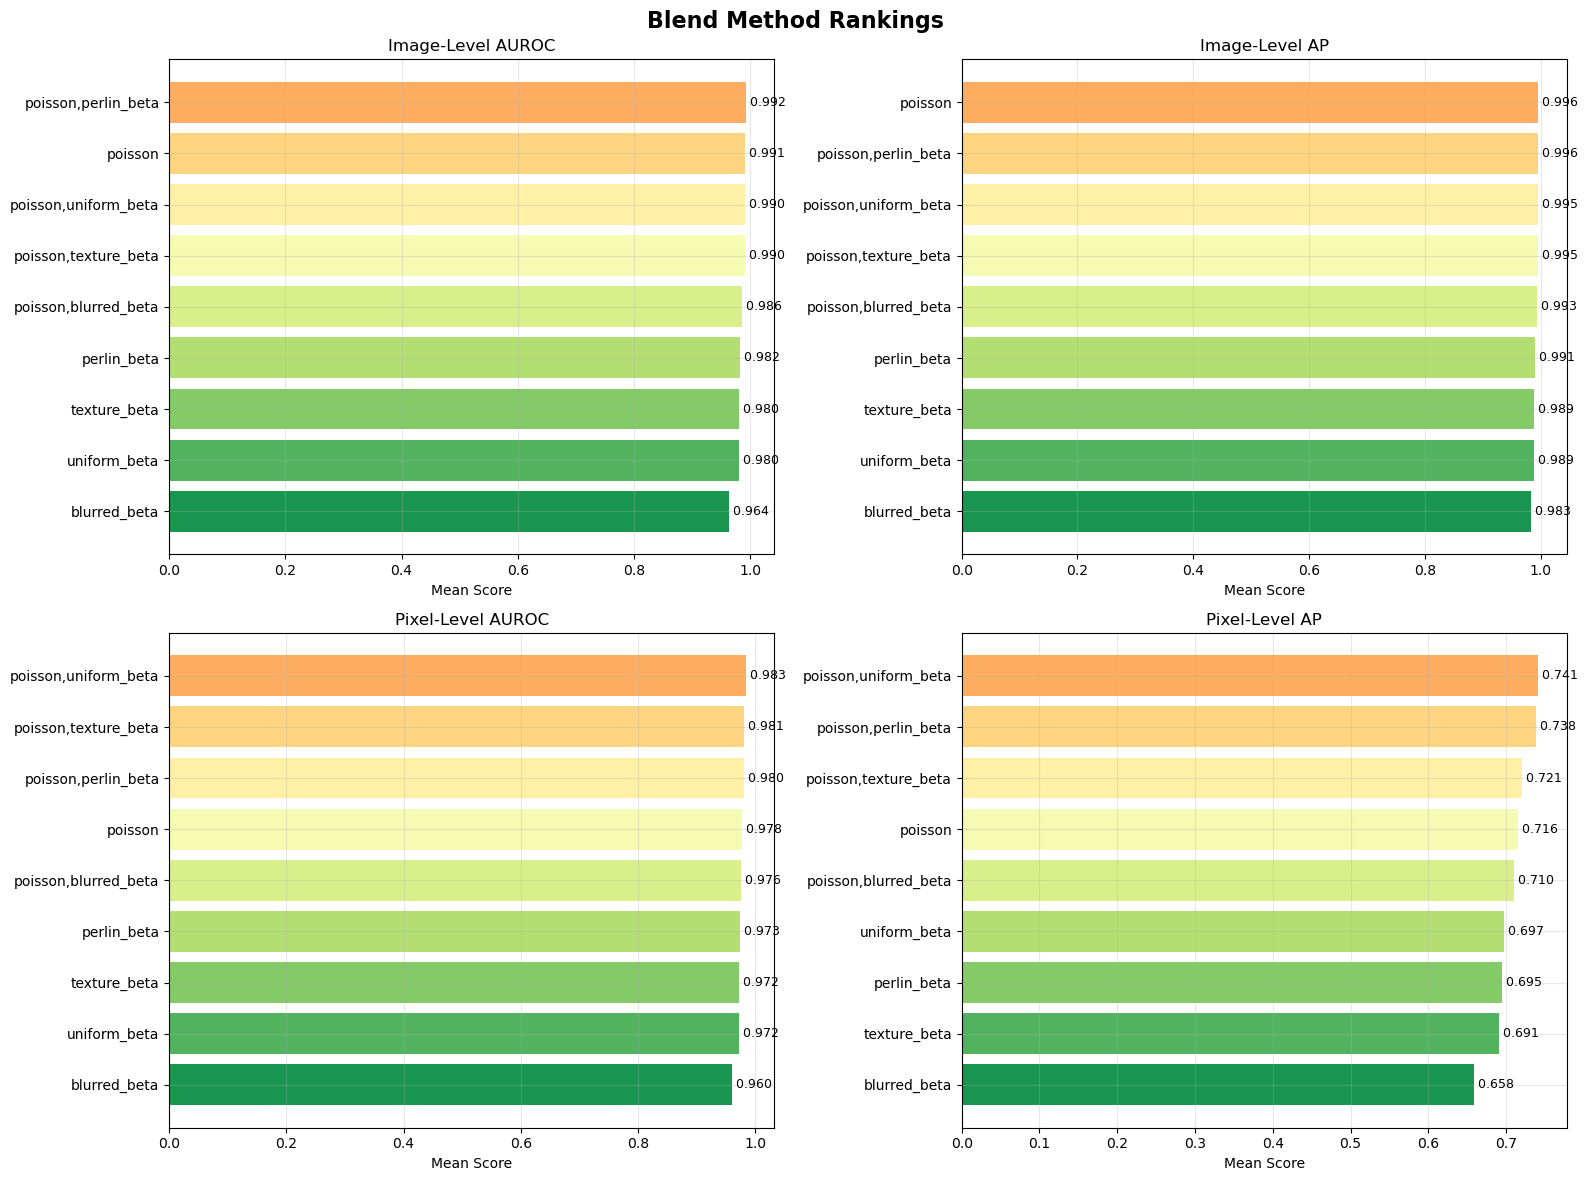

In [26]:
# Visualize rankings
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Blend Method Rankings', fontsize=16, fontweight='bold')

for idx, title in enumerate(metric_titles):
    ax = axes[idx // 2, idx % 2]
    
    data = ranking_df[ranking_df['metric'] == title].sort_values('rank')
    
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(data)))
    bars = ax.barh(data['blend_method'], data['score'], color=colors)
    
    ax.set_xlabel('Mean Score')
    ax.set_title(title)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # Add score labels
    for i, (score, method) in enumerate(zip(data['score'], data['blend_method'])):
        ax.text(score, i, f' {score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Best Blend Method per Object

In [27]:
# Find best blend method for each object
best_methods = {}

for metric, title in zip(metrics, metric_titles):
    print(f"\n{title}:")
    print("=" * 60)
    
    best_for_obj = {}
    
    for obj in objects:
        obj_data = df_clean[df_clean['obj_name'] == obj]
        if len(obj_data) > 0:
            best_method = obj_data.groupby('blend_method')[metric].mean().idxmax()
            best_score = obj_data.groupby('blend_method')[metric].mean().max()
            best_for_obj[obj] = (best_method, best_score)
            print(f"{obj:15s} -> {best_method:20s} (score: {best_score:.4f})")
    
    best_methods[title] = best_for_obj


Image-Level AUROC:
bottle          -> poisson              (score: 0.9994)
cable           -> poisson              (score: 0.9533)
capsule         -> poisson,perlin_beta  (score: 0.9984)
carpet          -> poisson,uniform_beta (score: 0.9807)
grid            -> poisson              (score: 1.0000)
hazelnut        -> perlin_beta          (score: 1.0000)
leather         -> poisson,perlin_beta  (score: 1.0000)
metal_nut       -> texture_beta         (score: 0.9985)
pill            -> poisson,blurred_beta (score: 0.9937)
screw           -> poisson,texture_beta (score: 0.9998)
tile            -> poisson              (score: 1.0000)
toothbrush      -> perlin_beta          (score: 1.0000)
transistor      -> poisson,uniform_beta (score: 0.9871)
wood            -> poisson              (score: 0.9996)
zipper          -> poisson,blurred_beta (score: 1.0000)

Image-Level AP:
bottle          -> poisson              (score: 0.9998)
cable           -> poisson              (score: 0.9748)
capsule    

In [28]:
# Count how often each blend method is the best
print("\nHow often is each blend method the best?")
print("=" * 60)

for title in metric_titles:
    print(f"\n{title}:")
    methods_count = defaultdict(int)
    
    for obj, (method, score) in best_methods[title].items():
        methods_count[method] += 1
    
    for method, count in sorted(methods_count.items(), key=lambda x: x[1], reverse=True):
        print(f"  {method:20s}: {count:2d} objects ({count/len(objects)*100:.1f}%)")


How often is each blend method the best?

Image-Level AUROC:
  poisson             :  5 objects (33.3%)
  poisson,perlin_beta :  2 objects (13.3%)
  poisson,uniform_beta:  2 objects (13.3%)
  perlin_beta         :  2 objects (13.3%)
  poisson,blurred_beta:  2 objects (13.3%)
  texture_beta        :  1 objects (6.7%)
  poisson,texture_beta:  1 objects (6.7%)

Image-Level AP:
  poisson             :  5 objects (33.3%)
  poisson,blurred_beta:  3 objects (20.0%)
  poisson,perlin_beta :  2 objects (13.3%)
  perlin_beta         :  2 objects (13.3%)
  poisson,uniform_beta:  1 objects (6.7%)
  texture_beta        :  1 objects (6.7%)
  poisson,texture_beta:  1 objects (6.7%)

Pixel-Level AUROC:
  poisson,texture_beta:  5 objects (33.3%)
  poisson,uniform_beta:  4 objects (26.7%)
  poisson,perlin_beta :  4 objects (26.7%)
  texture_beta        :  1 objects (6.7%)
  uniform_beta        :  1 objects (6.7%)

Pixel-Level AP:
  poisson,uniform_beta:  4 objects (26.7%)
  poisson,texture_beta:  3 obje

## 10. Summary and Conclusions

In [29]:
# Overall summary
print("\n" + "="*80)
print("SUMMARY: Blend Method Performance Analysis")
print("="*80)

print(f"\nTotal runs analyzed: {len(df_clean)}")
print(f"Blend methods: {len(blend_methods)}")
print(f"Objects: {len(objects)}")

print("\nOverall Best Performing Blend Methods:")
print("-" * 80)

for metric, title in zip(metrics, metric_titles):
    best_overall = df_clean.groupby('blend_method')[metric].mean().idxmax()
    best_score = df_clean.groupby('blend_method')[metric].mean().max()
    worst_overall = df_clean.groupby('blend_method')[metric].mean().idxmin()
    worst_score = df_clean.groupby('blend_method')[metric].mean().min()
    
    print(f"\n{title}:")
    print(f"  Best:  {best_overall:20s} (mean: {best_score:.4f})")
    print(f"  Worst: {worst_overall:20s} (mean: {worst_score:.4f})")
    print(f"  Improvement: {(best_score - worst_score):.4f} ({(best_score - worst_score)/worst_score*100:.1f}%)")


SUMMARY: Blend Method Performance Analysis

Total runs analyzed: 420
Blend methods: 9
Objects: 15

Overall Best Performing Blend Methods:
--------------------------------------------------------------------------------

Image-Level AUROC:
  Best:  poisson,perlin_beta  (mean: 0.9921)
  Worst: blurred_beta         (mean: 0.9636)
  Improvement: 0.0285 (3.0%)

Image-Level AP:
  Best:  poisson              (mean: 0.9956)
  Worst: blurred_beta         (mean: 0.9827)
  Improvement: 0.0129 (1.3%)

Pixel-Level AUROC:
  Best:  poisson,uniform_beta (mean: 0.9833)
  Worst: blurred_beta         (mean: 0.9602)
  Improvement: 0.0231 (2.4%)

Pixel-Level AP:
  Best:  poisson,uniform_beta (mean: 0.7410)
  Worst: blurred_beta         (mean: 0.6584)
  Improvement: 0.0826 (12.6%)


In [30]:
# Export summary to CSV
summary_export = df_clean.groupby('blend_method')[metrics].agg(['mean', 'std', 'min', 'max', 'count'])
summary_export.to_csv('blend_method_summary.csv')
print("\nSummary statistics exported to: blend_method_summary.csv")

# Export per-object results
per_obj_export = df_clean.pivot_table(
    values=metrics,
    index='obj_name',
    columns='blend_method',
    aggfunc='mean'
)
per_obj_export.to_csv('blend_method_per_object.csv')
print("Per-object results exported to: blend_method_per_object.csv")


Summary statistics exported to: blend_method_summary.csv
Per-object results exported to: blend_method_per_object.csv
